## Step 1: Import Libraries and Load Dataset

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv("F:\\Github_Desktop\\UNSUPERVISED-LEARNING-ALGORIDHAM\\mobile_recommendation_system_dataset copy.csv")
data.head()


,name,ratings,price,imgURL,corpus
0,"REDMI Note 12 Pro 5G (Onyx Black, 128 GB)",4.2,23999,https://rukminim2.flixcart.com/image/312/312/x...,Storage128 GBRAM6 SystemAndroid 12Processor T...
1,"OPPO F11 Pro (Aurora Green, 128 GB)",4.5,"₹20,999",https://rukminim2.flixcart.com/image/312/312/k...,Storage128 GBRAM6 GBExpandable Storage256GB S...
2,"REDMI Note 11 (Starburst White, 64 GB)",4.2,13149,https://rukminim2.flixcart.com/image/312/312/x...,Storage64 GBRAM4 SystemAndroid 11Processor Sp...
3,"OnePlus Nord CE 5G (Blue Void, 256 GB)",4.1,21999,https://rukminim2.flixcart.com/image/312/312/x...,Storage256 GBRAM12 SystemAndroid Q 11Processo...
4,"APPLE iPhone 13 mini (Blue, 128 GB)",4.6,3537,https://rukminim2.flixcart.com/image/312/312/k...,Storage128 SystemiOS 15Processor TypeA15 Bion...


## Step 2: Understand Dataset Shape & Structure

In [3]:

print("Shape of dataset:", data.shape)
print("\nColumn Information:")
data.info()


Shape of dataset: (2546, 5)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2546 entries, 0 to 2545
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   name     2546 non-null   object 
 1   ratings  2546 non-null   float64
 2   price    2546 non-null   object 
 3   imgURL   2546 non-null   object 
 4   corpus   2534 non-null   object 
dtypes: float64(1), object(4)
memory usage: 99.6+ KB


## Step 3: Data Cleaning (Missing Values & Data Types)

In [4]:

# Check missing values
print("Missing Values:\n", data.isnull().sum())

# Remove rows with missing corpus text if necessary
data = data.dropna(subset=['corpus'])
print("\nAfter cleaning, dataset shape:", data.shape)


Missing Values:
 name        0
ratings     0
price       0
imgURL      0
corpus     12
dtype: int64

After cleaning, dataset shape: (2534, 5)


## Step 4: Price Cleaning & Conversion

In [5]:

# Clean price column (remove ₹, commas, convert to int)
data['price'] = data['price'].astype(str).str.replace('₹','').str.replace(',','').astype(float)

# Check basic price stats
data['price'].describe()


count     2534.000000
mean     16974.611681
std       8605.435236
min         73.000000
25%      10499.000000
50%      15499.000000
75%      23463.000000
max      89999.000000
Name: price, dtype: float64

## Step 5: Descriptive Statistics

In [6]:

data.describe(include='all')


,name,ratings,price,imgURL,corpus
count,2534,2534.000000,2534.000000,2534,2534
unique,2128,NaN,NaN,1665,1603
top,"OPPO Reno10 5G (Ice Blue, 256 GB)",NaN,NaN,https://rukminim2.flixcart.com/image/312/312/x...,Storage256 GBRAM8 SystemAndroid 13Processor T...
freq,14,NaN,NaN,14,8
mean,NaN,4.296251,16974.611681,NaN,NaN
std,NaN,0.214859,8605.435236,NaN,NaN
min,NaN,2.900000,73.000000,NaN,NaN
25%,NaN,4.200000,10499.000000,NaN,NaN
50%,NaN,4.300000,15499.000000,NaN,NaN
75%,NaN,4.400000,23463.000000,NaN,NaN


## Step 6: Univariate Analysis (Ratings & Price Distribution)

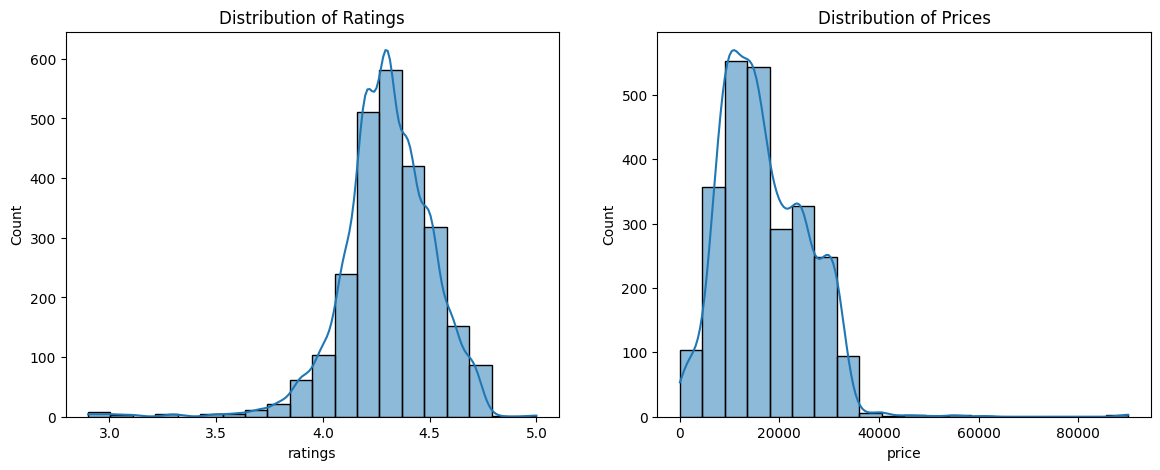

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(data['ratings'], kde=True, bins=20, ax=axes[0])
axes[0].set_title("Distribution of Ratings")
sns.histplot(data['price'], kde=True, bins=20, ax=axes[1])
axes[1].set_title("Distribution of Prices")
plt.show()


## Step 7: Bivariate Analysis (Ratings vs Price)

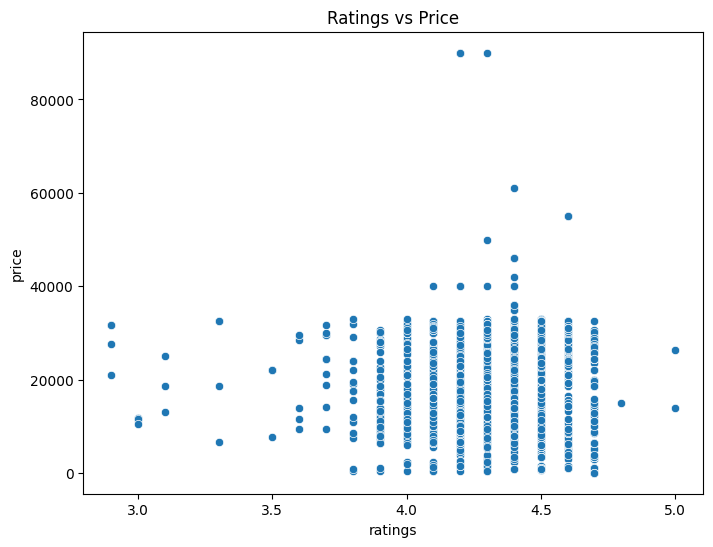

In [8]:

plt.figure(figsize=(8,6))
sns.scatterplot(x='ratings', y='price', data=data)
plt.title("Ratings vs Price")
plt.show()


## Step 8: Top Mobile Brands Analysis

C:\Users\HP\AppData\Local\Temp\ipykernel_12572\3101564376.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_counts.index, y=brand_counts.values, palette="viridis")


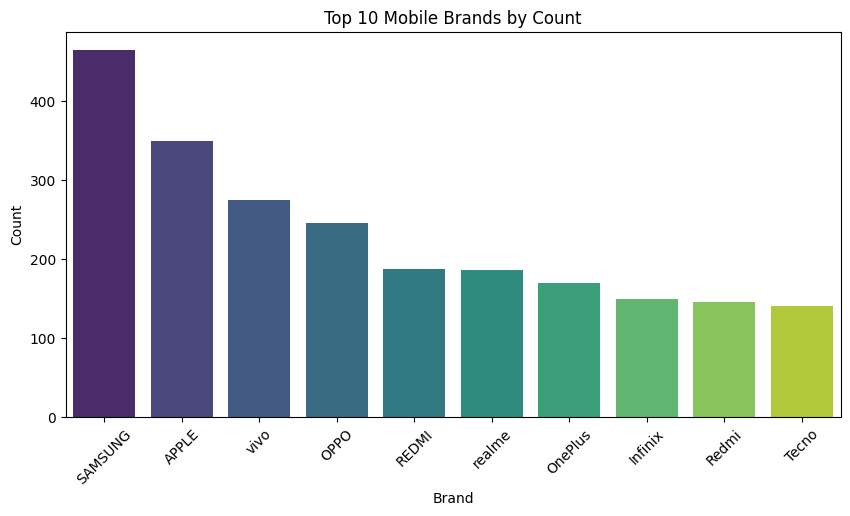

In [9]:

# Extract brand names (first word of name)
data['brand'] = data['name'].str.split().str[0]
brand_counts = data['brand'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=brand_counts.index, y=brand_counts.values, palette="viridis")
plt.title("Top 10 Mobile Brands by Count")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()
